In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from tqdm.notebook import tqdm

tqdm.pandas()


BASE_DIR = Path.cwd().resolve().parent
print(f"BASE_DIR: {BASE_DIR}")

PR_DIR = BASE_DIR / "data" / "processed"
print(f"PR_DIR: {PR_DIR}")

RW_DIR = BASE_DIR / "data" / "raw"
print(f"RW_DIR: {RW_DIR}")

BASE_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2
PR_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2\data\processed
RW_DIR: C:\Users\juanf\U\S7\5_bussiness\pr2\data\raw


# Cargar

In [5]:
cfdt = pd.read_csv(PR_DIR / "cleaned_food_delivery_times.csv")
cfdt.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


# Preparar datos

In [ ]:
cfdt = pd.get_dummies(
    cfdt,
    columns=["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"],
    drop_first=True,
)
cfdt.head()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,522,7.93,12,1.0,43,False,False,False,True,True,False,False,False,False,False,True
1,738,16.42,20,2.0,84,False,False,False,False,False,True,True,False,False,False,False
2,741,9.52,28,1.0,59,True,False,False,False,True,False,False,False,True,False,True
3,661,7.44,5,1.0,37,False,True,False,False,False,True,False,False,False,False,True
4,412,19.03,16,5.0,68,False,False,False,False,True,False,False,True,False,False,False


In [7]:
cfdt.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Preparation_Time_min    1000 non-null   int64  
 3   Courier_Experience_yrs  1000 non-null   float64
 4   Delivery_Time_min       1000 non-null   int64  
 5   Weather_Foggy           1000 non-null   bool   
 6   Weather_Rainy           1000 non-null   bool   
 7   Weather_Snowy           1000 non-null   bool   
 8   Weather_Windy           1000 non-null   bool   
 9   Traffic_Level_Low       1000 non-null   bool   
 10  Traffic_Level_Medium    1000 non-null   bool   
 11  Time_of_Day_Evening     1000 non-null   bool   
 12  Time_of_Day_Morning     1000 non-null   bool   
 13  Time_of_Day_Night       1000 non-null   bool   
 14  Vehicle_Type_Car        1000 non-null   bool   
 15 

## Split train, test, val

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = cfdt.drop(["Order_ID", "Delivery_Time_min"], axis=1)
y = cfdt["Delivery_Time_min"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=250
)

# Modelos

In [14]:
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import norm

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV


## XGBoost

In [15]:
xgb_regressor = xgb.XGBRegressor(objective="reg:squarederror", eval_metric="mae")

param_xgb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.1, 0.2],
    "max_depth": [3, 5, 10],
    "subsample": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

grid_search__xgb = GridSearchCV(xgb_regressor, param_xgb, cv=5)

grid_search__xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.2], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [16]:
grid_search__xgb.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 50,
 'subsample': 1.0}

In [17]:
best_gs_xgb_two = grid_search__xgb.best_estimator_

In [ ]:
y_test_pred1 = best_gs_xgb_two.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred1)

print("train : ", round(best_gs_xgb_two.score(X_train, y_train), 4))
print("test : ", round(best_gs_xgb_two.score(X_test, y_test), 4))
print("MAE on test : ", round(mae_test, 4))

train :  0.8004
test :  0.7936
MAE on test :  6.7974


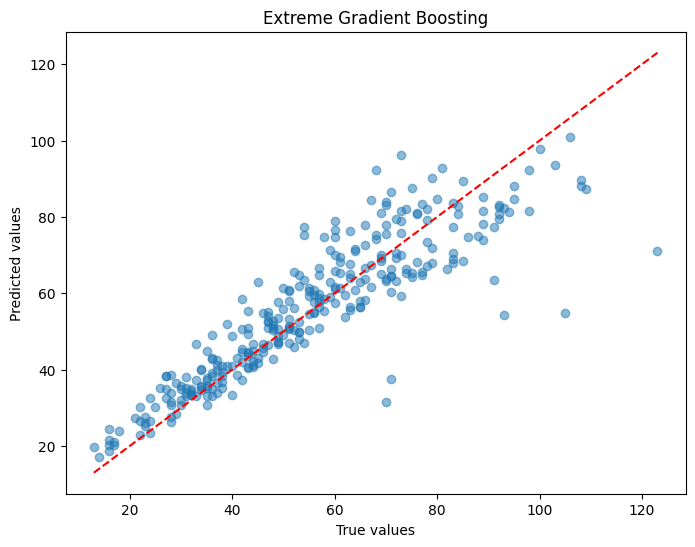

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred1, alpha=0.5)
plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--"
)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Extreme Gradient Boosting")
plt.show()

## LightGBM

In [ ]:
lgb_regressor = lgb.LGBMRegressor(objective="regression", metric="mae", verbose=-1)

param_lgb = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 10],
    "num_leaves": [31, 50, 100],
    "subsample": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

grid_search_lgb = GridSearchCV(
    lgb_regressor, param_lgb, cv=5, scoring="neg_mean_absolute_error"
)

grid_search_lgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMRegressor...', verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [ ]:
print("Best params:", grid_search_lgb.best_params_)

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'num_leaves': 31, 'subsample': 0.8}


In [22]:
best_lgb = grid_search_lgb.best_estimator_

In [ ]:
y_test_pred2 = best_lgb.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred2)

print("train :", round(best_lgb.score(X_train, y_train), 4))
print("test :", round(best_lgb.score(X_test, y_test), 4))
print("MAE on test :", round(mae_test, 4))

train : 0.817
test : 0.792
MAE on test : 6.7521


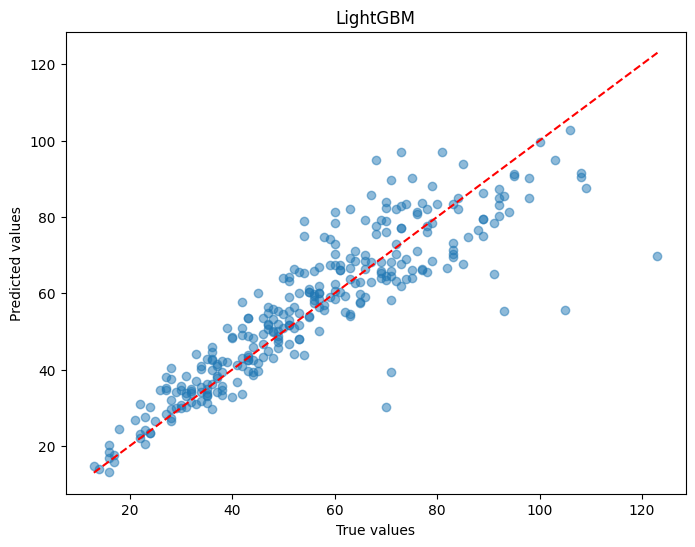

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred2, alpha=0.5)
plt.plot(
    [min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--"
)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("LightGBM")
plt.show()

# Guardar mejor modelo

El modelo xgboost tuvo MAE menor (Se equivoca en menos minutos al predecir), por lo que se usará ese

In [28]:
import joblib

model_dir = BASE_DIR / "data" / "models"


In [29]:
joblib.dump(best_gs_xgb_two, model_dir / "xgb_food_delivery.joblib")

['C:\\Users\\juanf\\U\\S7\\5_bussiness\\pr2\\data\\models\\xgb_food_delivery.joblib']

In [ ]:
# Cargar modelo

import joblib

model = joblib.load(model_dir / "xgb_food_delivery.joblib")
y_pred = model.predict(X_test)